In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  
import matplotlib.colors as mcolors
from dataclasses import dataclass
import sympy as sp

In [3]:
data = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        data[i][j] = i*j


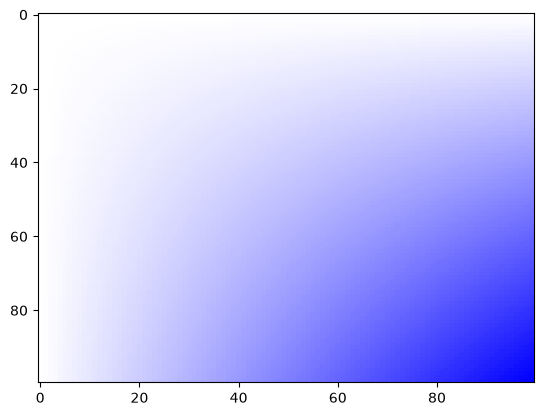

In [9]:
boje = ['white', 'blue']
moj_cmap = mcolors.LinearSegmentedColormap.from_list("BelaUPlavu", boje)
plt.imshow(data, cmap=moj_cmap, aspect='auto')

In [18]:
x, y= sp.symbols('x y', real=True)
f = sp.Add(2*x**3 + y**2, x **2 * y, evaluate=False)
sp.diff(f.args[0], x) + sp.diff(f.args[1], y)


7*x**2

In [29]:
x, y = sp.symbols('x y', real=True)

P = -x**3
Q = -y**3

dP_dx = sp.diff(P, x)  
dQ_dy = sp.diff(Q, y) 

div_simbolicko = dP_dx + dQ_dy    
print("Simbolička divergencija:", div_simbolicko)

izracunaj_div = sp.lambdify((x, y), div_simbolicko, 'numpy')
izracunaj_div(1,1)

Simbolička divergencija: -3*x**2 - 3*y**2


-6

In [34]:
def Divergence(P, Q, x_value, y_value):
    dP_dx = sp.diff(P, x)  
    dQ_dy = sp.diff(Q, y) 

    div_simbolicko = dP_dx + dQ_dy

    izracunaj_div = sp.lambdify((x, y), div_simbolicko, 'numpy')
    
    return izracunaj_div(x_value,y_value)

In [35]:
Divergence(-x**3, -y**3, 1, 1)

-6

In [53]:
P = -x**3
Q = -y**3

podaci_div = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        podaci_div[i][j] = Divergence(P, Q, i, j)

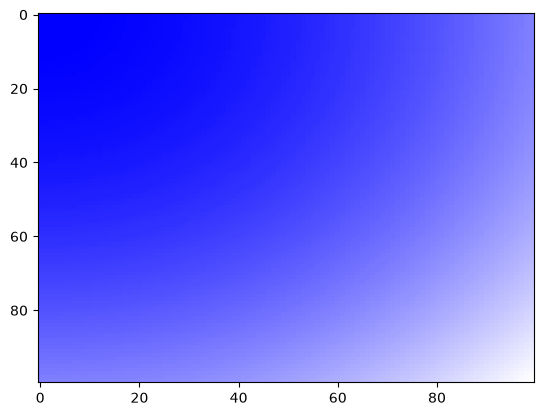

In [101]:
boje = ['white', 'blue']
moj_cmap = mcolors.LinearSegmentedColormap.from_list("BelaUPlavu", boje)
plt.imshow(podaci_div, cmap=moj_cmap, aspect='auto')

Izgleda da je ovaj kod malo neefekiasan i da postoji funkcija u numpy koja sve to radi umesto mene :(

*KLASA VEKTOR

In [102]:
class VectorField:
    def __init__(self, ime, x_grid, y_grid, u, v):
        self.ime = ime
        self.x_grid = x_grid
        self.y_grid = y_grid
        self.u = u
        self.v = v
    def DivergenceNew(self) -> np.ndarray:

        dx = self.x_grid[0, 1] - self.x_grid[0, 0]
        dy = self.y_grid[1, 0] - self.y_grid[0, 0]
        
        dU_dx = np.gradient(self.u, axis=1) / dx
        dV_dy = np.gradient(self.v, axis=0) / dy

        return dU_dx + dV_dy

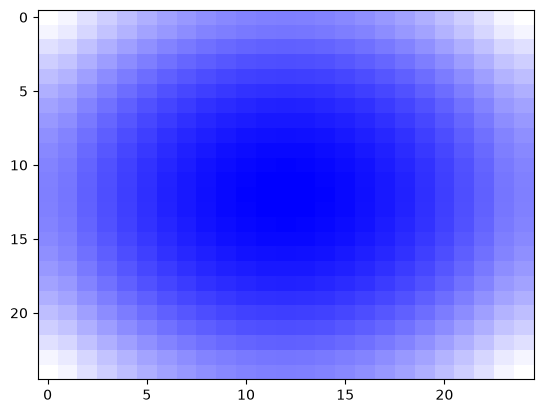

In [112]:
X, Y = np.meshgrid(np.linspace(-3,3,25), np.linspace(-3,3,25))
U = -X**3
V = -Y**3
field = VectorField(ime = 'voda', x_grid=X, y_grid=Y, u=U, v=V)
podaci = field.DivergenceNew()

plt.imshow(podaci, cmap=moj_cmap, aspect='auto')





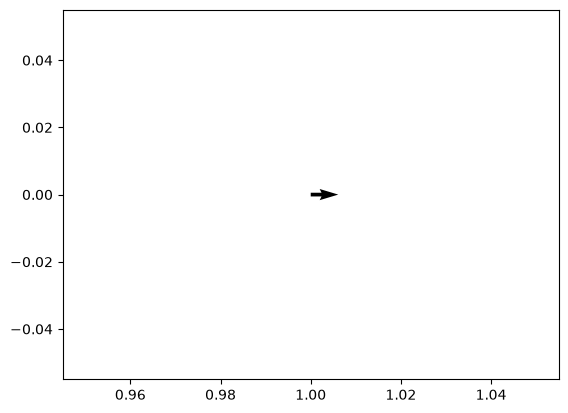

In [104]:
x = 1
y = 0
u = 1
v = 0
plt.quiver(x,y,u,v)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

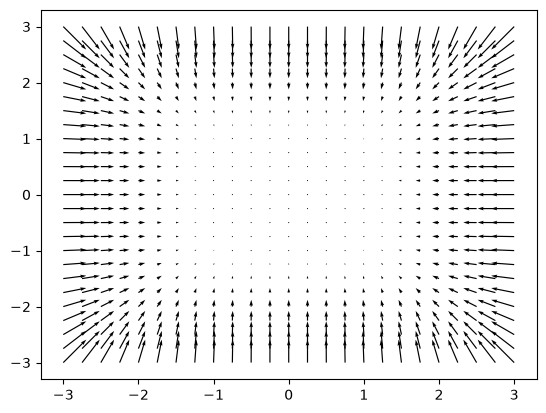

In [105]:
X, Y = np.meshgrid(np.linspace(-3,3,25), np.linspace(-3,3,25))
U = -X**3
V = -Y**3

plt.quiver(X,Y,U,V)
plt.show

STA SE DESAVA OVDE???

In [106]:
X, Y = np.meshgrid(np.linspace(-5,5,11), np.linspace(-5,5,11))
U = -X**3
V = -Y**3
Y

array([[-5., -5., -5., -5., -5., -5., -5., -5., -5., -5., -5.],
       [-4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.],
       [-3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.],
       [-2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.],
       [ 4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.],
       [ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.]])

<function matplotlib.pyplot.show(close=None, block=None)>

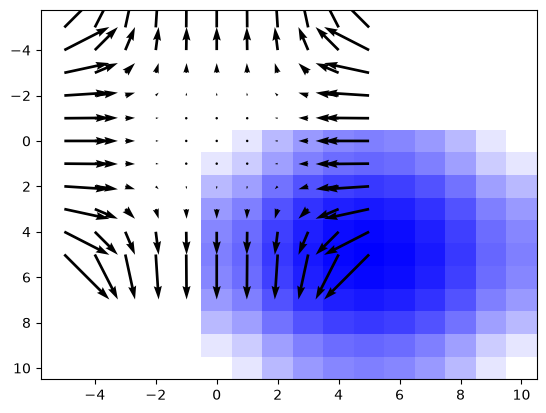

In [107]:
X, Y = np.meshgrid(np.linspace(-5,5,11), np.linspace(-5,5,11))
U = -X**3
V = -Y**3

plt.imshow(podaci, cmap=moj_cmap, aspect='auto')
plt.quiver(X,Y,U,V)
plt.show

pokusavamo sa pcolormesh

<function matplotlib.pyplot.show(close=None, block=None)>

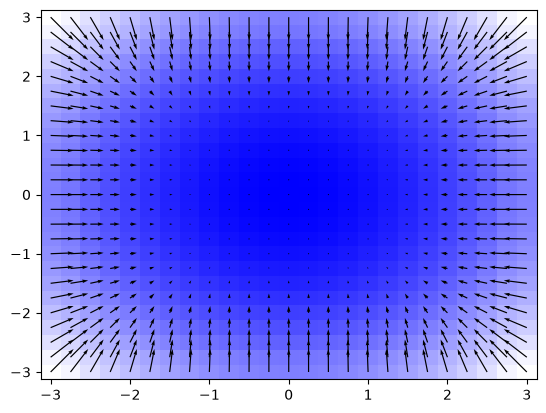

In [113]:
X, Y = np.meshgrid(np.linspace(-3,3,25), np.linspace(-3,3,25))
U = -X**3
V = -Y**3

plt.pcolormesh(X, Y, podaci, cmap=moj_cmap, shading='auto')
plt.quiver(X,Y,U,V)
plt.show